# Figure S2. Estimating UHVDB virus completeness

In [16]:
### Load mine reports for all mined viruses that were run through checkv
import polars as pl

# read uhvdb sequences
uhvdb_ids = set(pl.read_csv('../figure_1/uhvdb_source_data_with_hashes.tsv', separator='\t')['seq_name'])

# Load original mining report (genomad, checkv, and viralverify joined outputs)
mine_report_all = pl.read_csv('../figure_1/viruses.csvtk_concat.tsv', separator='\t', columns=['seq_name', 'completeness', 'completeness_method', 'proviral_length', 'contig_length'])

# filter mine report to only those in uhvdb
mine_report_uhvdb = (
    mine_report_all
        .filter(
            (pl.col('seq_name').is_in(uhvdb_ids))
        )
        .unique('seq_name')
)

In [17]:
### Count number of UHVDB genomes with DTR completeness method
(
    mine_report_uhvdb
        .filter(
            (pl.col('completeness_method').str.contains('DTR'))
        ).height
)

146144

In [37]:
### count number of sequences in each CheckV database version
print("CheckV v1.0.3 complete genomes:", pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/checkv/1.0.3/checkv_db/checkv-db-v1.5/genome_db/checkv_reps.tsv', separator='\t').unique('checkv_id').height)
print("CheckV UHGV:", pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/checkv/uhgv_1/genome_db/checkv_reps.tsv', separator='\t').unique('checkv_id').height)
print("CheckV v UHGV HQ HC:", pl.read_csv('../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/checkv_db/checkv_db_2026-03-23/genome_db/checkv_reps.tsv', separator='\t').unique('checkv_id').height)
print("CheckV v UHGV HQ LC:", pl.read_csv('../figure_1/uhgv_hq_lc_results/uhvdb_2026-03-25/checkv_db/checkv_db_2026-03-25/genome_db/checkv_reps.tsv', separator='\t').unique('checkv_id').height)
print("CheckV v UHVDB virus DB:", pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/checkv_db/checkv_db_2026-03-26/genome_db/checkv_reps.tsv', separator='\t').unique('checkv_id').height)
print("CheckV v UHVDB human metag:", pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/checkv_db/checkv_db_2026-03-26-2/genome_db/checkv_reps.tsv', separator='\t').unique('checkv_id').height)

CheckV v1.0.3 complete genomes: 62895
CheckV UHGV: 76460
CheckV v UHGV HQ HC: 76955
CheckV v UHGV HQ LC: 77090
CheckV v UHVDB virus DB: 99161
CheckV v UHVDB human metag: 121322


In [18]:
### count by confidence category using CheckV + UHGV
mine_report_all.group_by('completeness_method').len().sort('len', descending=True)

completeness_method,len
str,u32
"""NA""",4452395
"""AAI-based (high-confidence)""",1273617
"""HMM-based (lower-bound)""",518587
"""AAI-based (medium-confidence)""",249099
"""DTR (high-confidence)""",162045
…,…
"""ITR (high-confidence)""",9073
"""DTR (medium-confidence)""",5757
"""Provirus (high-confidence)""",5647


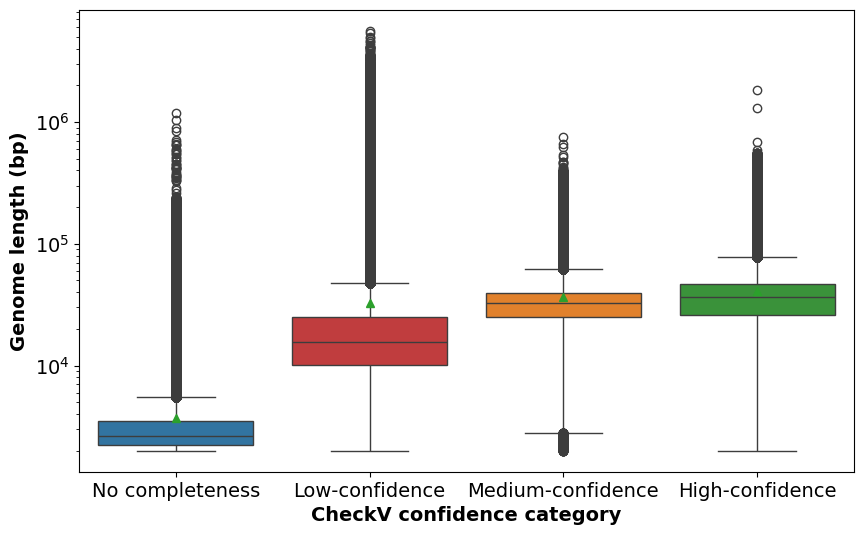

In [20]:
### plot length distribution by confidence category using CheckV + UHGV
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

checkv2_conf_plot = (
    mine_report_all
        .with_columns([
            pl.when(pl.col('completeness_method').str.contains('high')).then(pl.lit('High-confidence'))
                .when(pl.col('completeness_method').str.contains('medium')).then(pl.lit('Medium-confidence'))
                .when(pl.col('completeness_method').str.contains('lower')).then(pl.lit('Low-confidence'))
                .otherwise(pl.lit('No completeness'))
                .alias('completeness_method_cat'),
            pl.when(pl.col('contig_length').is_null()).then(pl.col('proviral_length')).otherwise(pl.col('contig_length')).cast(pl.Float64).alias('genome_length')
        ])
)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=checkv2_conf_plot, x='completeness_method_cat', y="genome_length", hue='completeness_method_cat',
    order=['No completeness', 'Low-confidence', 'Medium-confidence', 'High-confidence'], showmeans=True, legend=False)
plt.ylabel("Genome length (bp)", fontdict={'fontweight': 'bold'})
plt.xlabel("CheckV confidence category", fontdict={'fontweight': 'bold'})
plt.yscale('log')

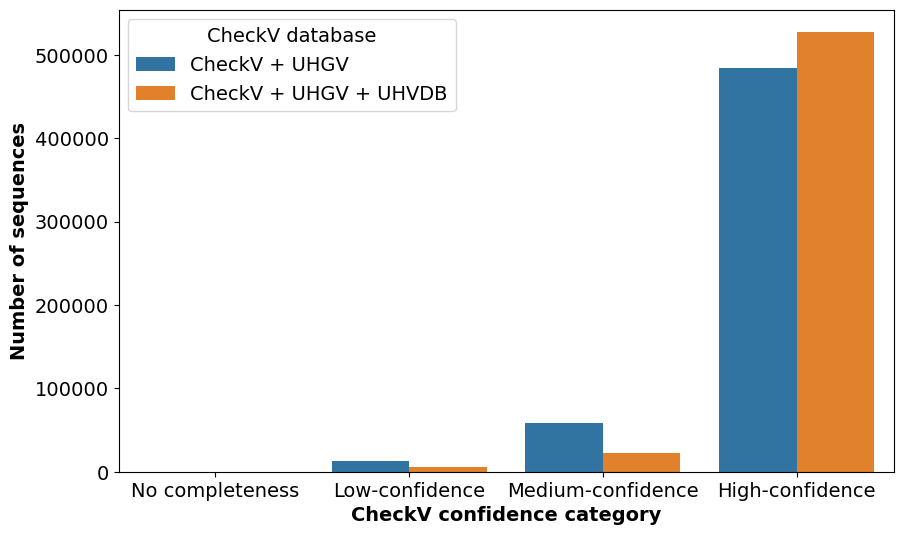

In [ ]:
### plot count by confidence category using each database
seqhasher = set(pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')['original_id'])

combined_checkv_df = (
    pl.concat([
        pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-23_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t'),
        pl.read_csv('../figure_1/uhgv_hq_lc_results/2026-03-25_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t'),
        pl.read_csv('../figure_1/uhvdb_virus_db_results/2026-03-26_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t', ignore_errors=True),
        pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t', ignore_errors=True)
    ])
    .filter(pl.col('contig_id').is_in(uhvdb_ids))
    .filter(~pl.col('contig_id').str.starts_with('UHGV-'))
)

uhvdb_db1_conf_plot = (
    mine_report_uhvdb
        .with_columns([
            pl.when(pl.col('completeness_method').str.contains('high')).then(pl.lit('High-confidence'))
                .when(pl.col('completeness_method').str.contains('medium')).then(pl.lit('Medium-confidence'))
                .when(pl.col('completeness_method').str.contains('lower')).then(pl.lit('Low-confidence'))
                .otherwise(pl.lit('No completeness'))
                .alias('completeness_method_cat')
        ])
)

db1_counts = (
    uhvdb_db1_conf_plot
        .group_by('completeness_method_cat').len()
        .rename({'completeness_method_cat':'CheckV confidence category', 'len': 'Count'})
        .with_columns(pl.lit('CheckV + UHGV').alias('CheckV database'))
)

db2_counts = (
    combined_checkv_df
        .with_columns([
            pl.when(pl.col('aai_confidence').str.contains('high')).then(pl.lit('High-confidence'))
                .when(pl.col('aai_confidence').str.contains('medium')).then(pl.lit('Medium-confidence'))
                .when(pl.col('aai_confidence').str.contains('low')).then(pl.lit('Low-confidence'))
                .otherwise(pl.lit('No completeness'))
                .alias('completeness_method_cat')
        ])
        .group_by('completeness_method_cat').len()
        .rename({'completeness_method_cat':'CheckV confidence category', 'len': 'Count'})
        .with_columns(pl.lit('CheckV + UHGV + UHVDB').alias('CheckV database'))
)

checkv_db_counts_plot = pl.concat([db1_counts, db2_counts])

plt.figure(figsize=(10, 6))
sns.barplot(checkv_db_counts_plot, x='CheckV confidence category', y='Count', hue='CheckV database',
    order=['No completeness', 'Low-confidence', 'Medium-confidence', 'High-confidence'])
plt.ylabel("Number of sequences", fontdict={'fontweight': 'bold'})
plt.xlabel("CheckV confidence category", fontdict={'fontweight': 'bold'})
plt.show()

In [38]:
checkv_db_counts_plot

CheckV confidence category,Count,CheckV database
str,u32,str
"""Low-confidence""",13268,"""CheckV + UHGV"""
"""Medium-confidence""",59027,"""CheckV + UHGV"""
"""High-confidence""",484285,"""CheckV + UHGV"""
"""No completeness""",25,"""CheckV + UHGV"""
"""High-confidence""",527724,"""CheckV + UHGV + UHVDB"""
"""Medium-confidence""",22965,"""CheckV + UHGV + UHVDB"""
"""Low-confidence""",5800,"""CheckV + UHGV + UHVDB"""
